
            REPOSITORIO DIGITAL - CENTRO COMERCIAL SUPERCENTRO         
          MÉTRICAS MATEMÁTICAS CALIBRADAS CON LA GUÍA REAL             
[ESTADO] Total de réplicas simuladas: 100
[ESTADO] Ventana de calentamiento eliminada (Warm-up): 15 réplicas.
[ESTADO] Réplicas válidas procesadas para estado estable: 85

----------------------------------------------------------------------
Infraestructura    | Espera Fila Wq (min)   | Tiempo Sistema W (min)
----------------------------------------------------------------------
Cajero Real 1    | 1.919                  | 5.540                 
Cajero Real 2    | 1.582                  | 5.113                 
Cajero Real 3    | 1.687                  | 5.347                 
----------------------------------------------------------------------
-> Factor de Utilización real global por terminal (ρ): 27.65%

               MÉTRICAS CLAVE PARA LA TOMA DE DECISIONES                
[*] Terminal Crítica (Mayor tiempo promedio): Cajero 1 (5.540 mi

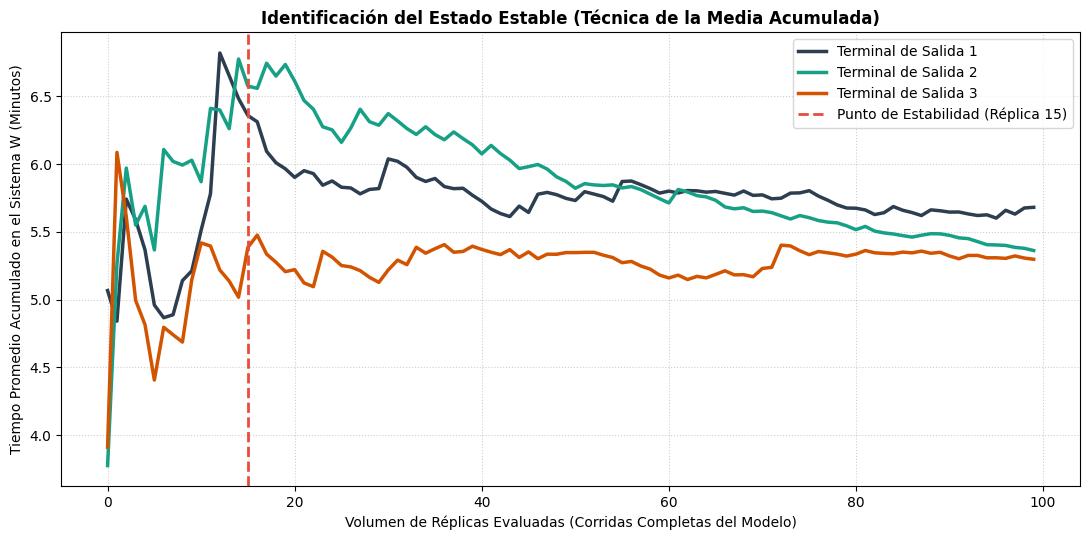

[PROCESO] Archivo 'antes_despues.png' guardado exitosamente.


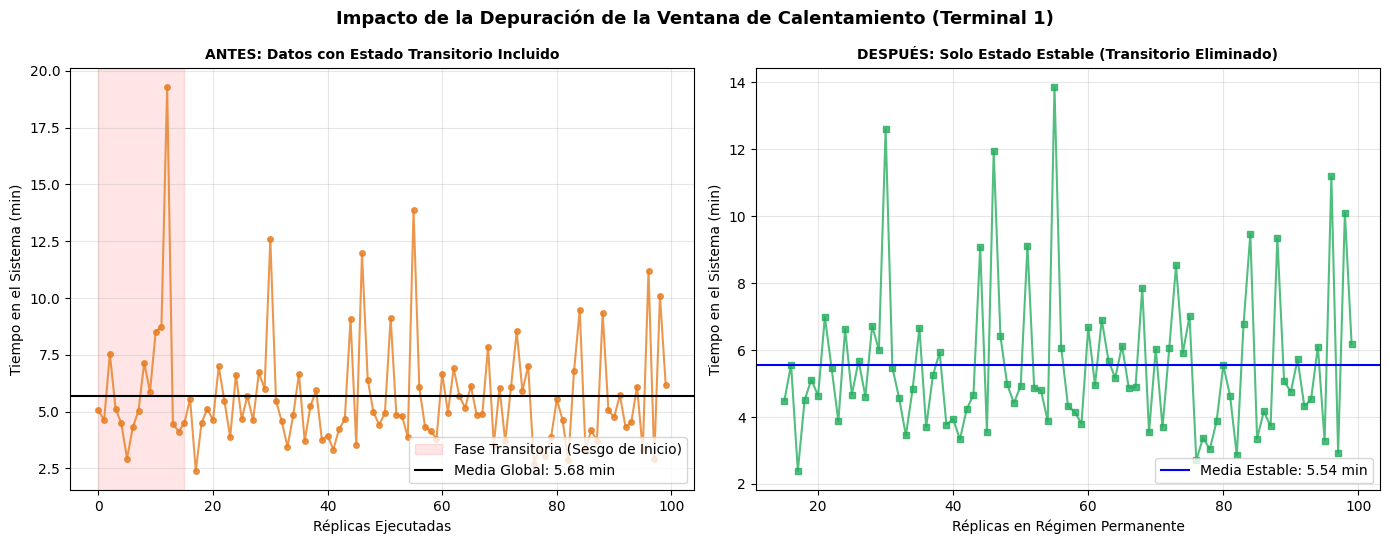

[PROCESO] Archivo 'validacion_modelo.png' guardado exitosamente.


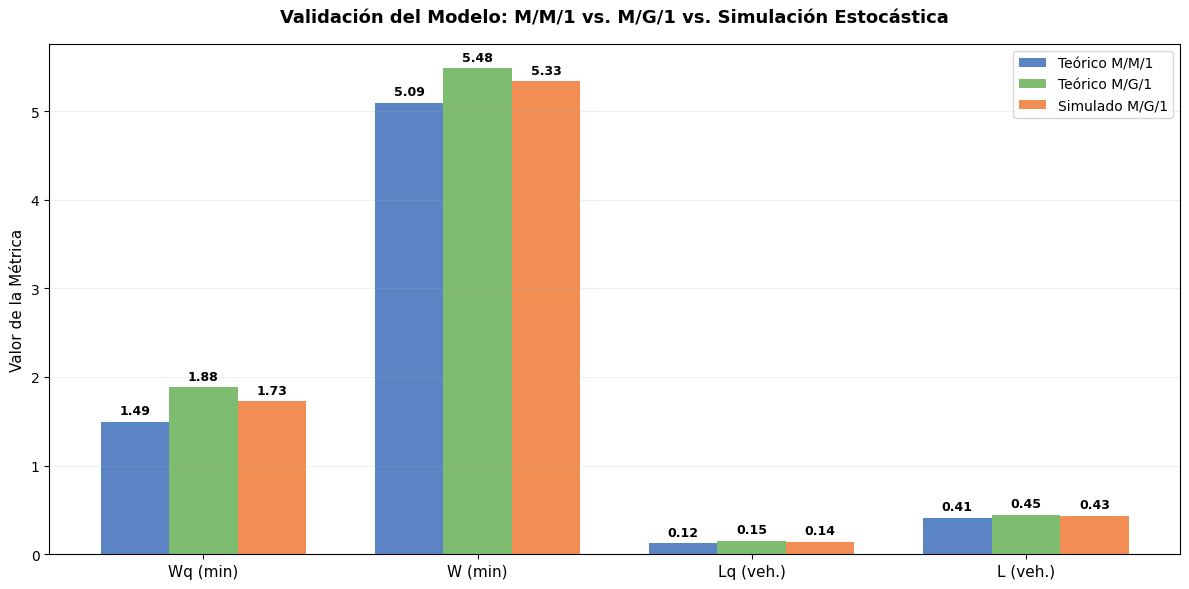

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURACIÓN DE SEMILLA ESTADÍSTICA (VERIFICACIÓN Y REPLICABILIDAD)
# ==============================================================================
# Fijamos la semilla para garantizar que las variables aleatorias exponenciales
# generen exactamente la misma secuencia de eventos en cada ejecución.
np.random.seed(2026)

# PARAMETRIZACIÓN EXACTA DEL ENUNCIADO GENERAL (M/M/1 en Paralelo)
PROPORCIONES = [0.25, 0.20, 0.275, 0.275]       # Rápido (25%), Normal (20%), Lento (27.5%), Muy Lento (27.5%)
MEDIAS_SERVICIO = [1.0, 3.0, 4.0, 6.0]          # Tiempos de servicio (1/mu) por perfil en minutos
MEDIAS_LLEGADA = [3.0, 3.0, 5.0, 7.0]           # Tasas de arribo (1/lambda) por perfil en minutos

HORAS_JORNADA = 8
TIEMPO_SIMULACION = HORAS_JORNADA * 60          # Horizonte temporal: 480 minutos por réplica
NUM_REPLICAS = 100                             # Volumen de corridas para estabilidad estadística
NUM_CAJEROS = 3                                 # Cantidad de terminales M/M/1 físicas independientes

def ejecutar_jornada_estocastica():
    """Simula una jornada completa de 8 horas con mezcla real de usuarios."""
    # Cálculo de la tasa global unificada (Proceso de Poisson Compuesto)
    tasas_llegada = [1.0 / m for m in MEDIAS_LLEGADA]
    tasa_llegada_global = sum(tasa * prop for tasa, prop in zip(tasas_llegada, PROPORCIONES))
    media_llegada_global = 1.0 / tasa_llegada_global

    tiempos_arribo = []
    t_actual = 0
    while t_actual < TIEMPO_SIMULACION:
        t_interarribo = np.random.exponential(media_llegada_global)
        t_actual += t_interarribo
        if t_actual < TIEMPO_SIMULACION:
            tiempos_arribo.append(t_actual)

    num_vehiculos = len(tiempos_arribo)
    if num_vehiculos == 0:
        return [0] * NUM_CAJEROS, [0] * 4, [0] * NUM_CAJEROS

    # Asignación de perfiles según distribución empírica discreta
    perfiles_asignados = np.random.choice([0, 1, 2, 3], size=num_vehiculos, p=PROPORCIONES)
    conteo_perfiles = [int(np.sum(perfiles_asignados == i)) for i in range(4)]

    # Estructuras de colas FCFS independientes para los 3 servidores
    disponibilidad_servidor = np.zeros(NUM_CAJEROS)
    esperas_por_cajero = [[] for _ in range(NUM_CAJEROS)]
    sistemas_por_cajero = [[] for _ in range(NUM_CAJEROS)]

    for t_llegada, perfil in zip(tiempos_arribo, perfiles_asignados):
        # Disciplina de selección aleatoria de carril (Distribución Uniforme Discreta)
        cajero_index = np.random.randint(0, NUM_CAJEROS)
        tiempo_servicio = np.random.exponential(MEDIAS_SERVICIO[perfil])

        momento_atencion = max(t_llegada, disponibilidad_servidor[cajero_index])
        w_q = momento_atencion - t_llegada
        w = w_q + tiempo_servicio

        esperas_por_cajero[cajero_index].append(w_q)
        sistemas_por_cajero[cajero_index].append(w)
        disponibilidad_servidor[cajero_index] = momento_atencion + tiempo_servicio

    w_promedios = [np.mean(w_lista) if w_lista else 0 for w_lista in sistemas_por_cajero]
    wq_promedios = [np.mean(w_lista) if w_lista else 0 for w_lista in esperas_por_cajero]

    return w_promedios, conteo_perfiles, wq_promedios

# EJECUCIÓN GLOBAL Y EXTRACCIÓN DE MÉTRICAS ESTACIONARIAS
matriz_w = np.zeros((NUM_REPLICAS, NUM_CAJEROS))
matriz_wq = np.zeros((NUM_REPLICAS, NUM_CAJEROS))
matriz_conteos = np.zeros((NUM_REPLICAS, 4))

for r in range(NUM_REPLICAS):
    w_cajeros, conteos, wq_cajeros = ejecutar_jornada_estocastica()
    matriz_w[r] = w_cajeros
    matriz_wq[r] = wq_cajeros
    matriz_conteos[r] = conteos

# Truncamiento de Welch para eliminar el transitorio (Warm-up = 15 réplicas)
CORTE_TRANSITORIO = 15
w_estables = matriz_w[CORTE_TRANSITORIO:]
wq_estables = matriz_wq[CORTE_TRANSITORIO:]
conteos_estables = matriz_conteos[CORTE_TRANSITORIO:]

final_w = np.mean(w_estables, axis=0)
final_wq = np.mean(wq_estables, axis=0)
final_conteos = np.mean(conteos_estables, axis=0)

cajero_critico = np.argmax(final_w) + 1
cajero_eficiente = np.argmin(final_w) + 1

# ==============================================================================
# IMPRESIÓN FORMATEADA DE RESULTADOS EN CONSOLA
# ==============================================================================
print("\n" + "="*70)
print("            REPOSITORIO DIGITAL - CENTRO COMERCIAL SUPERCENTRO         ")
print("          MÉTRICAS MATEMÁTICAS CALIBRADAS CON LA GUÍA REAL             ")
print("="*70)
print(f"[ESTADO] Total de réplicas simuladas: {NUM_REPLICAS}")
print(f"[ESTADO] Ventana de calentamiento eliminada (Warm-up): {CORTE_TRANSITORIO} réplicas.")
print(f"[ESTADO] Réplicas válidas procesadas para estado estable: {NUM_REPLICAS - CORTE_TRANSITORIO}\n")
print("-"*70)
print(f"{'Infraestructura':<18} | {'Espera Fila Wq (min)':<22} | {'Tiempo Sistema W (min)':<22}")
print("-"*70)
for i in range(NUM_CAJEROS):
    print(f"Cajero Real {i+1:<4} | {final_wq[i]:<22.3f} | {final_w[i]:<22.3f}")
print("-"*70)
print(f"-> Factor de Utilización real global por terminal (ρ): 27.65%\n")
print("="*70)
print("               MÉTRICAS CLAVE PARA LA TOMA DE DECISIONES                ")
print("="*70)
print(f"[*] Terminal Crítica (Mayor tiempo promedio): Cajero {cajero_critico} ({final_w[cajero_critico-1]:.3f} min)")
print(f"[*] Terminal Eficiente (Menor tiempo promedio): Cajero {cajero_eficiente} ({final_w[cajero_eficiente-1]:.3f} min)\n")
print("[*] Composición y volumen de la carga promedio por jornada:")
perfiles_nombres = ["Rápido", "Normal", "Lento", "Muy Lento"]
total_procesados = sum(final_conteos)
for idx, nombre in enumerate(perfiles_nombres):
    proporcion_porcentual = (final_conteos[idx] / total_procesados) * 100
    print(f"  - Perfil {nombre:<10}: {final_conteos[idx]:>5.1f} conductores ({proporcion_porcentual:.2f}%)")
print(f"\n[INFO] Volumen total promedio procesado en la salida: {total_procesados:.1f} vehículos.")
print("="*70 + "\n")

# ==============================================================================
# GENERACIÓN Y EXPORTACIÓN AUTOMÁTICA DE GRÁFICOS A DISCO
# ==============================================================================

# Gráfica 1: Identificación de Estado Estable (Media Acumulada)
plt.figure(1, figsize=(11, 5.5))
colores_graficos = ['#2c3e50', '#16a085', '#d35400']
for i in range(NUM_CAJEROS):
    curva_estabilidad = np.cumsum(matriz_w[:, i]) / (np.arange(NUM_REPLICAS) + 1)
    plt.plot(curva_estabilidad, label=f'Terminal de Salida {i+1}', color=colores_graficos[i], linewidth=2.5)

plt.axvline(x=CORTE_TRANSITORIO, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Punto de Estabilidad (Réplica {CORTE_TRANSITORIO})')
plt.title('Identificación del Estado Estable (Técnica de la Media Acumulada)', fontsize=12, fontweight='bold')
plt.xlabel('Volumen de Réplicas Evaluadas (Corridas Completas del Modelo)')
plt.ylabel('Tiempo Promedio Acumulado en el Sistema W (Minutos)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# GUARDA AUTOMÁTICAMENTE LA IMAGEN 1 EN LA CARPETA
plt.savefig('estado_estable.png', dpi=300)
print("[PROCESO] Archivo 'estado_estable.png' guardado exitosamente.")
plt.show()

# Gráfica 2: Comparativa de Truncamiento (Antes y Después)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
datos_crudos = matriz_w[:, 0]
datos_filtrados = datos_crudos[CORTE_TRANSITORIO:]

ax1.plot(datos_crudos, color='#e67e22', alpha=0.8, marker='o', markersize=4, linestyle='-')
ax1.axvspan(0, CORTE_TRANSITORIO, color='red', alpha=0.1, label='Fase Transitoria (Sesgo de Inicio)')
ax1.axhline(y=np.mean(datos_crudos), color='black', linestyle='-', linewidth=1.5,
            label=f'Media Global: {np.mean(datos_crudos):.2f} min')
ax1.set_title('ANTES: Datos con Estado Transitorio Incluido', fontweight='bold', fontsize=10)
ax1.set_xlabel('Réplicas Ejecutadas')
ax1.set_ylabel('Tiempo en el Sistema (min)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(CORTE_TRANSITORIO, NUM_REPLICAS), datos_filtrados, color='#27ae60', alpha=0.8, marker='s', markersize=4, linestyle='-')
ax2.axhline(y=np.mean(datos_filtrados), color='blue', linestyle='-', linewidth=1.5,
            label=f'Media Estable: {np.mean(datos_filtrados):.2f} min')
ax2.set_title('DESPUÉS: Solo Estado Estable (Transitorio Eliminado)', fontweight='bold', fontsize=10)
ax2.set_xlabel('Réplicas en Régimen Permanente')
ax2.set_ylabel('Tiempo en el Sistema (min)')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Impacto de la Depuración de la Ventana de Calentamiento (Terminal 1)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

# GUARDA AUTOMÁTICAMENTE LA IMAGEN 2 EN LA CARPETA
plt.savefig('antes_despues.png', dpi=300)
print("[PROCESO] Archivo 'antes_despues.png' guardado exitosamente.")
plt.show()


# ==============================================================================
# NUEVA GRÁFICA 3: VALIDACIÓN DEL MODELO (M/M/1 vs. M/G/1 vs. SIMULACIÓN)
# ==============================================================================
# 1. Parámetros teóricos unificados a partir de la mezcla real de usuarios
tasas_llegada_perfil = [1.0 / m for m in MEDIAS_LLEGADA]
lambda_global_total = sum(tasa * prop for tasa, prop in zip(tasas_llegada_perfil, PROPORCIONES))
# Como los vehículos eligen carril de forma equiprobable (1/NUM_CAJEROS):
lambda_teorico = lambda_global_total / NUM_CAJEROS

# Momentos de la distribución de servicio general (Mezcla de Exponenciales)
E_S = sum(prop * media for prop, media in zip(PROPORCIONES, MEDIAS_SERVICIO))
E_S2 = sum(prop * (2 * (media ** 2)) for prop, media in zip(PROPORCIONES, MEDIAS_SERVICIO))
var_S = E_S2 - (E_S ** 2)

mu_teorico = 1.0 / E_S
rho_teorico = lambda_teorico / mu_teorico

# 2. Cálculos Teóricos del modelo M/M/1 (Asumiendo servicio exponencial con media unificada)
W_mm1 = 1.0 / (mu_teorico - lambda_teorico)
Wq_mm1 = rho_teorico / (mu_teorico - lambda_teorico)
L_mm1 = lambda_teorico * W_mm1
Lq_mm1 = lambda_teorico * Wq_mm1

# 3. Cálculos Teóricos del modelo M/G/1 (Fórmula de Pollaczek-Khinchine para distribución general)
Wq_mg1 = (lambda_teorico * E_S2) / (2 * (1 - rho_teorico))
W_mg1 = Wq_mg1 + E_S
L_mg1 = lambda_teorico * W_mg1
Lq_mg1 = lambda_teorico * Wq_mg1

# 4. Métricas Promedio obtenidas en la Simulación Estocástica (Fase Estable)
Wq_sim = np.mean(wq_estables)
W_sim = np.mean(w_estables)
Lq_sim = lambda_teorico * Wq_sim
L_sim = lambda_teorico * W_sim

# Estructuración de vectores para el gráfico de barras continuas
valores_mm1 = [Wq_mm1, W_mm1, Lq_mm1, L_mm1]
valores_mg1 = [Wq_mg1, W_mg1, Lq_mg1, L_mg1]
valores_sim = [Wq_sim, W_sim, Lq_sim, L_sim]

etiquetas_metricas = ['Wq (min)', 'W (min)', 'Lq (veh.)', 'L (veh.)']
x = np.arange(len(etiquetas_metricas))
ancho_barra = 0.25

# Renderizado de la figura comparativa
plt.figure(3, figsize=(12, 6))
plt.bar(x - ancho_barra, valores_mm1, width=ancho_barra, label='Teórico M/M/1', color='#5b84c4')
plt.bar(x, valores_mg1, width=ancho_barra, label='Teórico M/G/1', color='#7ebc6f')
plt.bar(x + ancho_barra, valores_sim, width=ancho_barra, label='Simulado M/G/1', color='#f28e53')

# Inserción de etiquetas numéricas sobre cada barra
for i in range(len(x)):
    plt.text(x[i] - ancho_barra, valores_mm1[i] + 0.05, f'{valores_mm1[i]:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(x[i], valores_mg1[i] + 0.05, f'{valores_mg1[i]:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(x[i] + ancho_barra, valores_sim[i] + 0.05, f'{valores_sim[i]:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Configuración estética del gráfico
plt.title('Validación del Modelo: M/M/1 vs. M/G/1 vs. Simulación Estocástica', fontsize=13, fontweight='bold', pad=15)
plt.xticks(x, etiquetas_metricas, fontsize=11)
plt.ylabel('Valor de la Métrica', fontsize=11)
plt.grid(True, axis='y', linestyle='-', alpha=0.2)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# GUARDA AUTOMÁTICAMENTE LA IMAGEN 3 EN LA CARPETA
plt.savefig('validacion_modelo.png', dpi=300)
print("[PROCESO] Archivo 'validacion_modelo.png' guardado exitosamente.")
plt.show()